# PPO (Stable-Baselines3) — LunarLander-v2 (2000 Episodes)

Same experiment as the hand-written PPO notebook, now powered by **Stable-Baselines3**.
All outputs (episode reward plot, steps plot, loss plot, entropy plot, video, evaluation)
are identical in structure so results can be directly compared.

SB3 advantages over a hand-written implementation:
- Battle-tested, numerically stable PPO with proper value normalisation
- Automatic vectorised environments
- Built-in callback system for per-episode logging
- `evaluate_policy` utility for clean evaluation

Install if needed:
```
pip install stable-baselines3[extra]
```

In [1]:
# Imports
import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt
import glob
from collections import deque
from IPython.display import Video, display

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import VecVideoRecorder

VERSION       = 'ppo_v1'   # used to namespace all output files
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'SB3 version: {__import__("stable_baselines3").__version__}')
print(f'PyTorch:     {torch.__version__}')
print(f'Device:      {"cuda" if torch.cuda.is_available() else "cpu"}')

SB3 version: 2.3.2
PyTorch:     2.0.1+cu118
Device:      cuda


In [2]:
# ── Config — mirrors the hand-written PPO notebook exactly ───────────────────
ENV_NAME      = 'LunarLander-v2'
NUM_ENVS      = 8          # parallel environments
NUM_EPISODES  = 2000       # target episodes (training stops when this is reached)
MAX_STEPS     = 1000       # max steps per episode

# SB3 PPO hyperparameters — matched to hand-written version
LEARNING_RATE = 1e-4
GAMMA         = 0.99
GAE_LAMBDA    = 0.95
CLIP_EPS      = 0.2
VALUE_COEF    = 0.25
ENTROPY_COEF  = 0.01
MAX_GRAD_NORM = 0.5
N_STEPS       = 1024       # rollout steps per env (= ROLLOUT_STEPS // NUM_ENVS)
BATCH_SIZE    = 256        # mini-batch size
N_EPOCHS      = 4          # PPO update epochs per rollout

# Approximate total timesteps to cover NUM_EPISODES
# LunarLander average episode ~ 200-400 steps; use 500 as conservative estimate
TOTAL_TIMESTEPS = NUM_EPISODES * 500

SOLVE_REWARD  = 200
SOLVE_WINDOW  = 100

print('Config set.')
print(f'Training for ~{TOTAL_TIMESTEPS:,} timesteps (~{NUM_EPISODES} episodes)')

Config set.
Training for ~1,000,000 timesteps (~2000 episodes)


In [3]:
# ── Episode tracking callback ────────────────────────────────────────────────
# SB3 trains by timesteps, not episodes. This callback captures
# per-episode rewards/steps/losses so we can produce identical plots.

class EpisodeLogger(BaseCallback):
    """
    Logs per-episode reward, steps, and SB3 training losses
    so we can reproduce the same 4-panel plot as the hand-written PPO.
    """
    def __init__(self, solve_reward=SOLVE_REWARD, solve_window=SOLVE_WINDOW, verbose=0):
        super().__init__(verbose)
        self.rewards_history = []
        self.steps_history   = []
        self.loss_history    = []   # collected at each PPO update
        self.rolling         = deque(maxlen=solve_window)
        self.solve_reward    = solve_reward
        self.solve_window    = solve_window
        self.solved_at       = None
        self._ep_rewards     = None
        self._ep_steps       = None

    def _on_training_start(self):
        n = self.training_env.num_envs
        self._ep_rewards = np.zeros(n)
        self._ep_steps   = np.zeros(n, dtype=int)

    def _on_step(self) -> bool:
        rewards = self.locals['rewards']
        dones   = self.locals['dones']

        self._ep_rewards += rewards
        self._ep_steps   += 1

        for i, done in enumerate(dones):
            if done:
                ep = len(self.rewards_history) + 1
                self.rewards_history.append(self._ep_rewards[i])
                self.steps_history.append(self._ep_steps[i])
                self.rolling.append(self._ep_rewards[i])

                roll_mean = np.mean(self.rolling)
                if ep % 50 == 0:
                    print(f'Ep {ep:4d} | steps {self._ep_steps[i]:4d} | '
                          f'reward {self._ep_rewards[i]:8.2f} | '
                          f'rolling{self.solve_window} {roll_mean:7.2f}')

                if (self.solved_at is None
                        and len(self.rolling) == self.solve_window
                        and roll_mean >= self.solve_reward):
                    self.solved_at = ep
                    print(f'\n*** SOLVED at episode {ep} '
                          f'(rolling mean = {roll_mean:.2f}) ***\n')

                self._ep_rewards[i] = 0
                self._ep_steps[i]   = 0

        return True  # continue training

    def _on_rollout_end(self):
        # Grab loss values logged by SB3 into its logger
        logs = self.model.logger.name_to_value
        self.loss_history.append({
            'actor':   logs.get('train/policy_gradient_loss', 0.0),
            'critic':  logs.get('train/value_loss', 0.0),
            'entropy': logs.get('train/entropy_loss', 0.0),
            'total':   logs.get('train/loss', 0.0),
        })

print('EpisodeLogger callback defined.')

EpisodeLogger callback defined.


In [4]:
# ── Build vectorised environment & SB3 PPO model ────────────────────────────
vec_env = make_vec_env(ENV_NAME, n_envs=NUM_ENVS, seed=SEED)

model = PPO(
    policy          = 'MlpPolicy',
    env             = vec_env,
    learning_rate   = LEARNING_RATE,
    gamma           = GAMMA,
    gae_lambda      = GAE_LAMBDA,
    clip_range      = CLIP_EPS,
    vf_coef         = VALUE_COEF,
    ent_coef        = ENTROPY_COEF,
    max_grad_norm   = MAX_GRAD_NORM,
    n_steps         = N_STEPS,
    batch_size      = BATCH_SIZE,
    n_epochs        = N_EPOCHS,
    policy_kwargs   = dict(net_arch=[256, 256]),   # matches hand-written 256-256 trunk
    seed            = SEED,
    verbose         = 0,   # we handle printing in the callback
)

print(model.policy)
total_params = sum(p.numel() for p in model.policy.parameters())
print(f'\nTotal parameters: {total_params:,}')

ActorCriticPolicy(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (pi_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (vf_features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (mlp_extractor): MlpExtractor(
    (policy_net): Sequential(
      (0): Linear(in_features=8, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
    (value_net): Sequential(
      (0): Linear(in_features=8, out_features=256, bias=True)
      (1): Tanh()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): Tanh()
    )
  )
  (action_net): Linear(in_features=256, out_features=4, bias=True)
  (value_net): Linear(in_features=256, out_features=1, bias=True)
)

Total parameters: 137,477


In [5]:
# ── Train ────────────────────────────────────────────────────────────────────
print(f'=== PPO (SB3) — LunarLander-v2 (~{NUM_EPISODES} episodes) ===')
print(f'Total timesteps: {TOTAL_TIMESTEPS:,} across {NUM_ENVS} parallel envs\n')

callback = EpisodeLogger()

model.learn(
    total_timesteps = TOTAL_TIMESTEPS,
    callback        = callback,
    progress_bar    = False,
)

train_rewards = callback.rewards_history
train_steps   = callback.steps_history
train_losses  = callback.loss_history

print(f'\nTraining complete.')
print(f'Episodes completed : {len(train_rewards)}')
if callback.solved_at:
    print(f'Solved at episode  : {callback.solved_at}')
else:
    rm = np.mean(list(callback.rolling)) if callback.rolling else float('nan')
    print(f'Final rolling mean : {rm:.2f} (threshold {SOLVE_REWARD})')

=== PPO (SB3) — LunarLander-v2 (~2000 episodes) ===
Total timesteps: 1,000,000 across 8 parallel envs

Ep   50 | steps  105 | reward  -125.21 | rolling100 -182.19
Ep  100 | steps  135 | reward  -114.63 | rolling100 -185.15
Ep  150 | steps  113 | reward    30.92 | rolling100 -175.36
Ep  200 | steps   63 | reward   -50.53 | rolling100 -151.63
Ep  250 | steps   73 | reward   -96.23 | rolling100 -142.95
Ep  300 | steps   87 | reward  -162.77 | rolling100 -142.67
Ep  350 | steps  118 | reward  -199.21 | rolling100 -147.67
Ep  400 | steps   83 | reward  -185.78 | rolling100 -157.83
Ep  450 | steps   97 | reward  -193.49 | rolling100 -148.88
Ep  500 | steps  101 | reward  -138.86 | rolling100 -141.37
Ep  550 | steps  117 | reward  -139.75 | rolling100 -131.82
Ep  600 | steps   74 | reward   -90.49 | rolling100 -119.70
Ep  650 | steps  129 | reward   -66.22 | rolling100 -119.00
Ep  700 | steps   92 | reward   -88.53 | rolling100 -116.15
Ep  750 | steps  137 | reward  -209.99 | rolling100 -115.

In [6]:
# ── Save model ───────────────────────────────────────────────────────────────
model.save('ppo_v1_model')
print('Model saved to ppo_v1_model.zip')
# To reload: model = PPO.load('ppo_sb3_lunarlander')

Model saved to ppo_v1_model.zip


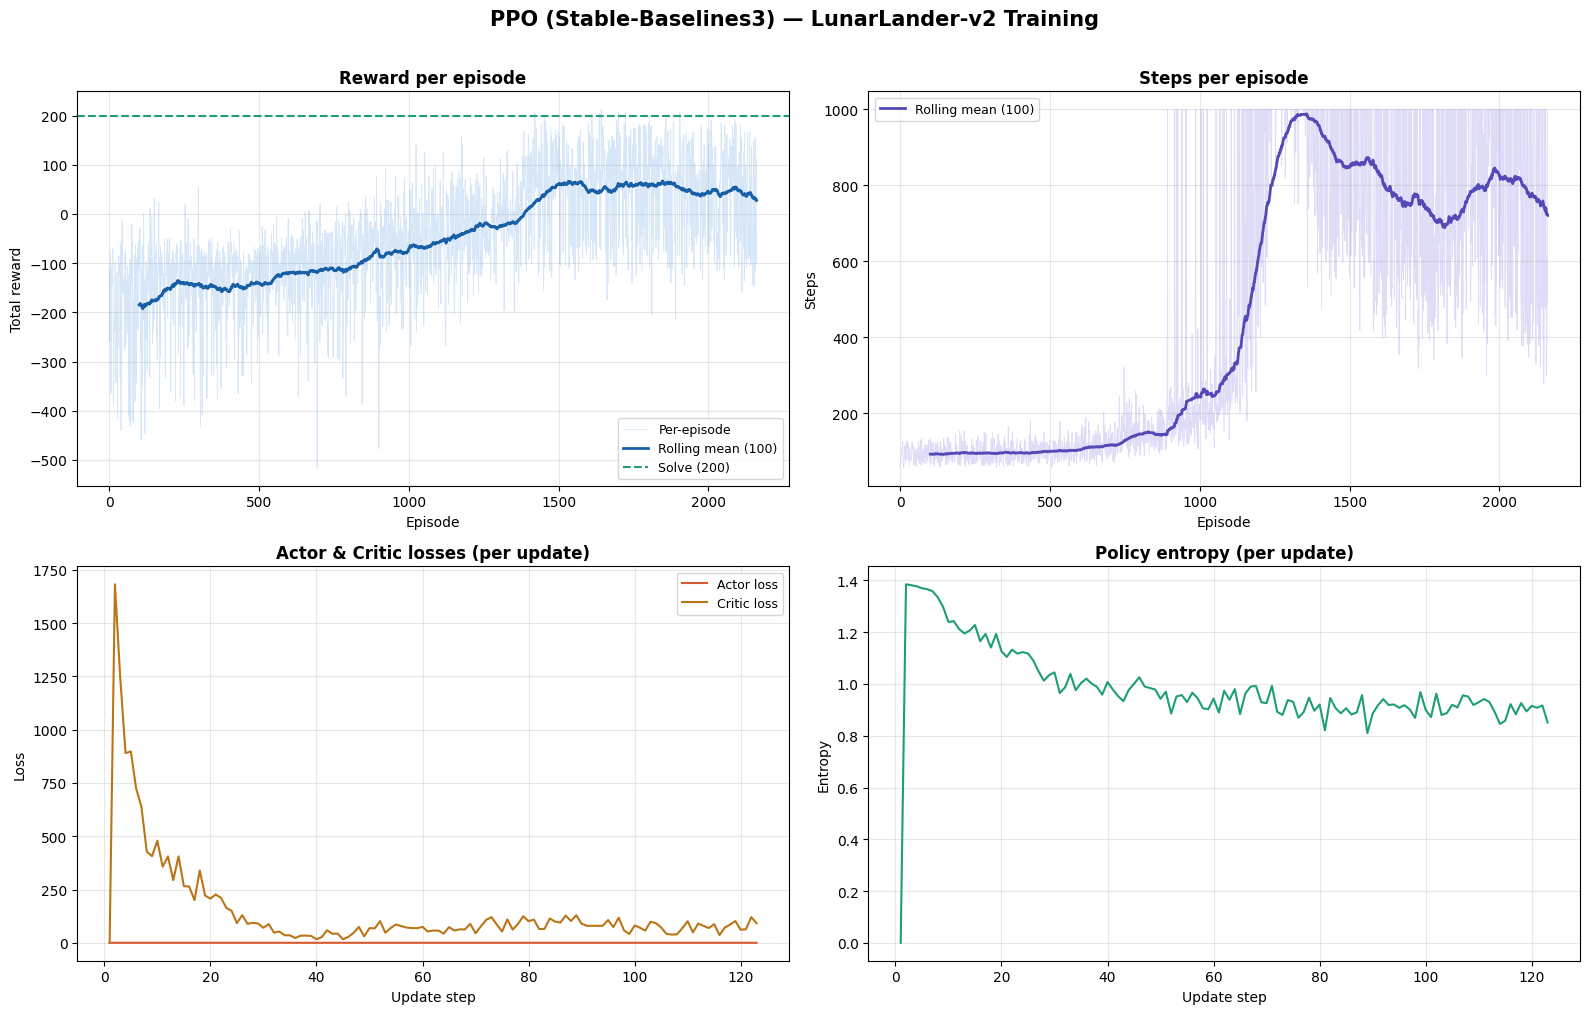

Curves saved to ppo_sb3_training_curves.png


In [7]:
# ── Plot training curves — identical 2x2 layout to hand-written PPO ──────────
rewards_arr = np.array(train_rewards)
episodes    = np.arange(1, len(rewards_arr) + 1)

def rolling_mean(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PPO (Stable-Baselines3) — LunarLander-v2 Training',
             fontsize=15, fontweight='bold', y=1.01)

# ── 1. Reward per episode + rolling mean
ax = axes[0, 0]
ax.plot(episodes, rewards_arr, alpha=0.2, color='#378ADD', linewidth=0.6, label='Per-episode')
if len(rewards_arr) >= 100:
    rm = rolling_mean(rewards_arr, 100)
    ax.plot(np.arange(100, len(rewards_arr) + 1), rm,
            color='#185FA5', linewidth=2, label='Rolling mean (100)')
ax.axhline(SOLVE_REWARD, color='#1D9E75', linestyle='--', linewidth=1.5,
           label=f'Solve ({SOLVE_REWARD})')
ax.set_title('Reward per episode', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Total reward')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 2. Steps per episode
ax = axes[0, 1]
ax.plot(episodes, train_steps, alpha=0.25, color='#7F77DD', linewidth=0.6)
if len(train_steps) >= 100:
    ax.plot(np.arange(100, len(train_steps) + 1),
            rolling_mean(np.array(train_steps, dtype=float), 100),
            color='#534AB7', linewidth=2, label='Rolling mean (100)')
ax.set_title('Steps per episode', fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Steps')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 3. Actor & Critic losses (from SB3 logger)
ax = axes[1, 0]
if train_losses:
    updates  = np.arange(1, len(train_losses) + 1)
    actor_l  = [l['actor']  for l in train_losses]
    critic_l = [l['critic'] for l in train_losses]
    ax.plot(updates, actor_l,  label='Actor loss',  color='#D85A30', linewidth=1.5)
    ax.plot(updates, critic_l, label='Critic loss', color='#BA7517', linewidth=1.5)
ax.set_title('Actor & Critic losses (per update)', fontweight='bold')
ax.set_xlabel('Update step'); ax.set_ylabel('Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── 4. Policy entropy
ax = axes[1, 1]
if train_losses:
    entropy_l = [-l['entropy'] for l in train_losses]
    ax.plot(updates, entropy_l, color='#1D9E75', linewidth=1.5)
ax.set_title('Policy entropy (per update)', fontweight='bold')
ax.set_xlabel('Update step'); ax.set_ylabel('Entropy')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_v1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curves saved to ppo_sb3_training_curves.png')

In [8]:
# ── Summary statistics — identical format to hand-written PPO ────────────────
r = np.array(train_rewards)
print('=== Training Summary ===')
print(f'Episodes trained   : {len(r)}')
print(f'Mean reward        : {r.mean():.2f}')
print(f'Std reward         : {r.std():.2f}')
print(f'Best episode       : {r.max():.2f}')
print(f'Worst episode      : {r.min():.2f}')
if len(r) >= SOLVE_WINDOW:
    final_mean = r[-SOLVE_WINDOW:].mean()
    status = 'SOLVED' if final_mean >= SOLVE_REWARD else 'not yet solved'
    print(f'Final {SOLVE_WINDOW}-ep mean   : {final_mean:.2f} ({status})')

=== Training Summary ===
Episodes trained   : 2161
Mean reward        : -46.66
Std reward         : 119.22
Best episode       : 212.76
Worst episode      : -516.00
Final 100-ep mean   : 27.50 (not yet solved)


In [9]:
# ── Record video — same tag/folder convention as hand-written PPO ────────────
def record_video(model, folder='./videos/ppo_v1', tag='ppo-sb3-agent', n_steps=MAX_STEPS):
    """
    Record one greedy episode using the trained SB3 model.
    Uses the same folder/tag convention as the hand-written PPO notebook.
    """
    env = gym.make(ENV_NAME, render_mode='rgb_array')
    env = gym.wrappers.RecordVideo(
        env, folder,
        episode_trigger=lambda e: True,
        name_prefix=tag
    )
    obs, _ = env.reset(seed=0)
    total_reward, steps = 0, 0
    for _ in range(n_steps):
        # SB3 predict() returns (action, state); deterministic=True = greedy
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            break
    env.close()
    print(f'Recorded: {steps} steps, reward {total_reward:.2f}')
    files = sorted(glob.glob(f'{folder}/{tag}*.mp4'))
    if files:
        display(Video(files[-1], embed=True, width=600))

print('Recording video of trained SB3 PPO agent...')
record_video(model)

Recording video of trained SB3 PPO agent...
Moviepy - Building video e:\University 5B\CS AI\videos\ppo_v1\ppo-sb3-agent-episode-0.mp4.
Moviepy - Writing video e:\University 5B\CS AI\videos\ppo_v1\ppo-sb3-agent-episode-0.mp4



Moviepy - Done !
Moviepy - video ready e:\University 5B\CS AI\videos\ppo_v1\ppo-sb3-agent-episode-0.mp4
Recorded: 384 steps, reward -148.26


In [10]:
# ── Evaluation — uses SB3 evaluate_policy + mirrors hand-written format ──────
print('=== Evaluation (20 episodes, greedy) ===')

eval_env = gym.make(ENV_NAME)

# SB3 built-in evaluator
mean_reward, std_reward = evaluate_policy(
    model, eval_env,
    n_eval_episodes=20,
    deterministic=True,
    return_episode_rewards=False
)
eval_env.close()

# Per-episode breakdown — mirrors hand-written PPO eval output
eval_rewards, eval_steps = [], []
eval_env2 = gym.make(ENV_NAME)
for ep in range(20):
    obs, _ = eval_env2.reset(seed=ep)
    total, steps = 0, 0
    for _ in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = eval_env2.step(action)
        total += reward; steps += 1
        if terminated or truncated:
            break
    eval_rewards.append(total)
    eval_steps.append(steps)
    print(f'Eval ep {ep+1:3d}: {steps:4d} steps, reward {total:8.2f}')
eval_env2.close()

print(f'\nEval mean (SB3): {mean_reward:.2f} +/- {std_reward:.2f}')
print(f'Eval mean (manual): {np.mean(eval_rewards):.2f} +/- {np.std(eval_rewards):.2f}')

=== Evaluation (20 episodes, greedy) ===


c:\Users\ninaw\AppData\Local\Programs\Python\Python311\Lib\site-packages\stable_baselines3\common\evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval ep   1:  384 steps, reward  -148.26
Eval ep   2: 1000 steps, reward   -61.32
Eval ep   3: 1000 steps, reward   -45.73
Eval ep   4:  913 steps, reward    87.61
Eval ep   5:  813 steps, reward    96.72
Eval ep   6: 1000 steps, reward   -70.74
Eval ep   7:  975 steps, reward  -174.05
Eval ep   8: 1000 steps, reward  -123.92
Eval ep   9:  760 steps, reward  -172.63
Eval ep  10:  388 steps, reward   -81.08
Eval ep  11:  615 steps, reward  -151.19
Eval ep  12:  622 steps, reward   131.15
Eval ep  13: 1000 steps, reward   -23.55
Eval ep  14:  756 steps, reward  -167.02
Eval ep  15:  605 steps, reward  -166.88
Eval ep  16:  906 steps, reward    90.61
Eval ep  17: 1000 steps, reward   -64.63
Eval ep  18:  579 steps, reward  -113.43
Eval ep  19:  451 steps, reward   -78.93
Eval ep  20: 1000 steps, reward   -39.43

Eval mean (SB3): -104.92 +/- 52.54
Eval mean (manual): -63.83 +/- 94.81
